## NMF Model 

This notebook contains the models for NMF and LDA. 
For each model, they were tested from K = 20 to K = 100.

NMF provided better results at the initial testing. 
- To improve the model, different parameters were tested such as adding n_grams, changing max_df and min_df.

In [1]:
# Imports

import os 
import shutil
import ast 
import pickle 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Gensim Stuff
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

# Scikit Learn - For NMF Topic Modelling 
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF
from sklearn.metrics import silhouette_score 
from sklearn.metrics.pairwise import cosine_similarity

# BERTopic Stuff 
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic

print("All imports done") 

All imports done


### Preprocessing

- I have the output already saved as songs_preprocessed.parquet, but I've put the chunk with the preprocessing below.
- It's the same as what Ishita did. 

Other than that, can proceed to loading of data in the following cell after.

In [ ]:
# Pre Processing 

# 1. Dropping columns not needed
cols_to_drop = ['key', 'mode', 'loudness', 'liveness',
                'acousticness', 'instrumentalness', 'tempo',
                'duration_ms', 'album_name', 'artist_ids']

songs_df = songs_df.drop(columns=cols_to_drop)
print("Remaining Columns:", songs_df.columns.tolist())

# 2. Drop songs with timestamps in lyrics 
has_timestamp = songs_df['lyrics'].str.contains(
    r'\[\d{2}:\d{2}\.\d{2,3}\]', regex=True, na=False
)
print("Songs with timestamps:", has_timestamp.sum())

# 3. Drop songs with timestamps in the lyrics
songs_df = songs_df[~has_timestamp]
print("Songs remaining:", len(songs_df))

# 4. Drop Songs with Repeated Lines - Reduce noise 
songs_df['lyrics_clean'] = songs_df['lyrics']

def remove_repeated_lines(text):
    lines = text.split('\n')
    cleaned = []
    previous_line = None
    
    for line in lines:
        line = line.strip()
        if line != previous_line and line != '':
            cleaned.append(line)
            previous_line = line
    
    return '\n'.join(cleaned)

songs_df['lyrics_clean'] = songs_df['lyrics_clean'].apply(remove_repeated_lines)

# 4. Tokenize cleaned lyrics and count words
songs_df['tokens'] = songs_df['lyrics_clean'].apply(word_tokenize)

songs_df['word_count'] = songs_df['tokens'].apply(len)

# 5. Drop songs with very short lyircs (Keep songs with more than 20 words) 
print("Before dropping songs with less than 20 words:", len(songs_df))
songs_df = songs_df[songs_df['word_count'] >= 20]
print("")
print("After dropping songs with less than 20 words:", len(songs_df))

#6. Pre Process Lyrics 
stop_words = set(stopwords.words('english'))
lyrics_stopwords = {
    'yeah', 'oh', 'ooh', 'ah', 'na', 'la', 'ha',
    'gonna', 'wanna', 'gotta', 'chorus', 'verse',
    'hook', 'bridge', 'repeat', 'whoa', 'aye', 'ay'
}
stop_words.update(lyrics_stopwords)
lemmatizer = WordNetLemmatizer()

def process_lyrics(text):
    text = text.replace('\n', ' ')
    
    tokens_lower = word_tokenize(text.lower())
    tokens_alpha = [t for t in tokens_lower if re.search('^[a-z]+$',t)]
    tokens_stop = [t for t in tokens_alpha if t not in stop_words]
    tokens_lem = [lemmatizer.lemmatize(t) for t in tokens_stop]
    return tokens_lem

# Re run on lyrics 
songs_df['tokens_lemma'] = songs_df['lyrics_clean'].apply(process_lyrics)

# Check the same song again
print(songs_df['tokens_lemma'].iloc[0][:15])

### Load Preprocessed Data below.

file was saved as a parquet due to my laptop storage

In [ ]:
songs_df = pd.read_parquet("./data/songs_preprocessed.parquet")

# "token_lemma" stores a list of cleaned words originally. will need to convert them back to actual python lists after saving it to parquet. 

def safe_parse(val):
    if isinstance(val, (list, np.ndarray)): 
        return list(val)
    
    try: 
        return ast.literal_eval(val) 
    
    except: 
        return val.strip("[]").replace("'", "").split(",")
    
songs_df['tokens_lemma'] = songs_df["tokens_lemma"].apply(safe_parse) 

# For NMF (TF-IDF Vectoriser) and BERTopic (CountVectorizer) - I create a tokens_joined, where ceaned tokens are joined back into string for count. 

songs_df['tokens_joined'] = songs_df['tokens_lemma'].apply(lambda x: " ".join(x))

print(f" Loaded dataset: {songs_df.shape[0]:,} songs, {songs_df.shape[1]} columns.")
songs_df[['name', 'genre', 'popularity', 'tokens_lemma','tokens_joined']].head(5)

 Loaded dataset: 548,698 songs, 19 columns.


,name,genre,popularity,tokens_lemma,tokens_joined
0,!,Rock,0,"[said, came, jamaica, owned, couple, acre, cou...",said came jamaica owned couple acre couple fak...
1,!!,Hip-Hop,29,"[fuck, bitch, running, said, never, thing, wor...",fuck bitch running said never thing word said ...
2,!!Noble Stabbings!!,Rock,0,"[like, stand, side, point, laugh, line, drawn,...",like stand side point laugh line drawn plain c...
3,!I'll Be Back!,Hip-Hop,43,"[shit, missed, rehab, psyche, gone, ai, room, ...",shit missed rehab psyche gone ai room rest dem...
4,!Lost!,Hip-Hop,0,"[would, like, give, time, would, like, tell, m...",would like give time would like tell much love...


### LDA Model Portion
- Items are saved in lda, with model, dict, corpus and results created.
- Separated into: 
1. Loading In Files/Creation of LDA 
2. Evaluation Using Coherence Score and Perplexity. 

- Coherence - measures how semantically similar the top words in each topic are. Higher is better. 

In [ ]:
# Tuning LDA Model from K = 20 to K = 100
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

coherence_values = []
model_list = []
topic_range = range(20, 101, 5)  # testing from K = 20 to K = 100 

for k in topic_range:
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        alpha='auto'
    )
    cm = CoherenceModel(model=model, texts=songs_df['tokens_lemma'],
                        dictionary=dictionary, coherence='c_v')
    coherence_values.append(cm.get_coherence())
    model_list.append(model)
    print(f"k={k}  Coherence: {cm.get_coherence():.4f}")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(topic_range, coherence_values, marker='o')
plt.xlabel("Number of Topics (k)")
plt.ylabel("Coherence Score (c_v)")
plt.title("LDA — Coherence Score vs Number of Topics")
plt.xticks(list(topic_range))
plt.grid(True)
plt.tight_layout()
plt.savefig("lda_coherence_vs_k.png", bbox_inches='tight')
plt.show()

# Pick the best k
best_k = list(topic_range)[coherence_values.index(max(coherence_values))]
best_model = model_list[coherence_values.index(max(coherence_values))]
print(f"\nBest k = {best_k}  (Coherence: {max(coherence_values):.4f})")


NameError: name 'corpus' is not defined

In [1]:
import csv
import os
from gensim.models import LdaModel, CoherenceModel
from gensim import corpora

# Previous saved so it doesnt run again
LDA_DICT_PATH   = "./lda/lda_dictionary.dict"
LDA_CORPUS_PATH = "./lda/lda_corpus.mm"
RESULTS_CSV     = "./lda/lda_tuning_results.csv"
MODELS_DIR      = "./lda/tuning_models/"
os.makedirs(MODELS_DIR, exist_ok=True)

# Load dictionary & corpus 
dictionary = corpora.Dictionary.load(LDA_DICT_PATH)
corpus     = list(corpora.MmCorpus(LDA_CORPUS_PATH))
texts      = songs_df['tokens_lemma'].tolist()  # for coherence

print(f"Dictionary: {len(dictionary):,} tokens | Corpus: {len(corpus):,} docs")

# ── Write CSV header if file doesn't exist ────────────────────────────────
if not os.path.exists(RESULTS_CSV):
    with open(RESULTS_CSV, 'w', newline='') as f:
        csv.writer(f).writerow(['k', 'coherence_cv', 'diversity'])
    already_done = set()
else:
    # Resume from where it left off if it crashed
    import pandas as pd
    done_df = pd.read_csv(RESULTS_CSV)
    already_done = set(done_df['k'].tolist())
    print(f"Resuming — already completed: {sorted(already_done)}")

# k = 20 to k = 100 testing
k_values = range(20, 101, 5)

for k in k_values:
    if k in already_done:
        print(f"Skipping k={k} (already done)")
        continue

    print(f"\nTraining LDA k={k}...", end=' ', flush=True)

    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        chunksize=2000,
        alpha='auto',
        eta='auto'
    )

    # Coherence
    cm = CoherenceModel(
        model=lda,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence = round(cm.get_coherence(), 4)

    # Diversity
    topic_words_list = [[w for w, _ in lda.show_topic(t, topn=10)] for t in range(k)]
    all_w = [w for words in topic_words_list for w in words]
    diversity = round(len(set(all_w)) / len(all_w), 4)

    print(f"Coherence={coherence} | Diversity={diversity}")

    # Save result immediately
    with open(RESULTS_CSV, 'a', newline='') as f:
        csv.writer(f).writerow([k, coherence, diversity])

    # Save model for best k retrieval later
    lda.save(f"{MODELS_DIR}lda_model_k{k}")

# ── Summary ───────────────────────────────────────────────────────────────
import pandas as pd
results_df = pd.read_csv(RESULTS_CSV).sort_values('k')
best = results_df.loc[results_df['coherence_cv'].idxmax()]
print(f"\n✅ Tuning complete!")
print(f"Best k={int(best['k'])} | Coherence={best['coherence_cv']} | Diversity={best['diversity']}")
print(results_df.to_string(index=False))

FileNotFoundError: [Errno 2] No such file or directory: './lda/lda_dictionary.dict'

### Evaluation
- This section the LDA Coherence Score and Perplexity. 

In [12]:
coherence_model = CoherenceModel(
    model = lda_model,
    texts = songs_df['tokens_lemma'],
    dictionary = dictionary, 
    coherence = 'c_v'
)

coherence_score = coherence_model.get_coherence()
log_perplexity_score = lda_model.log_perplexity(corpus) 
perplexity_score = 2**(-log_perplexity_score)

print(f" LDA Coherence Score: {coherence_score:.4f}.")
print(f" LDA Coherence Score: {log_perplexity_score:.4f}.")
print(f" LDA Perplexity : {perplexity_score:.4f}.")

 LDA Coherence Score: 0.4745.
 LDA Coherence Score: -7.7123.
 LDA Perplexity : 209.7170.


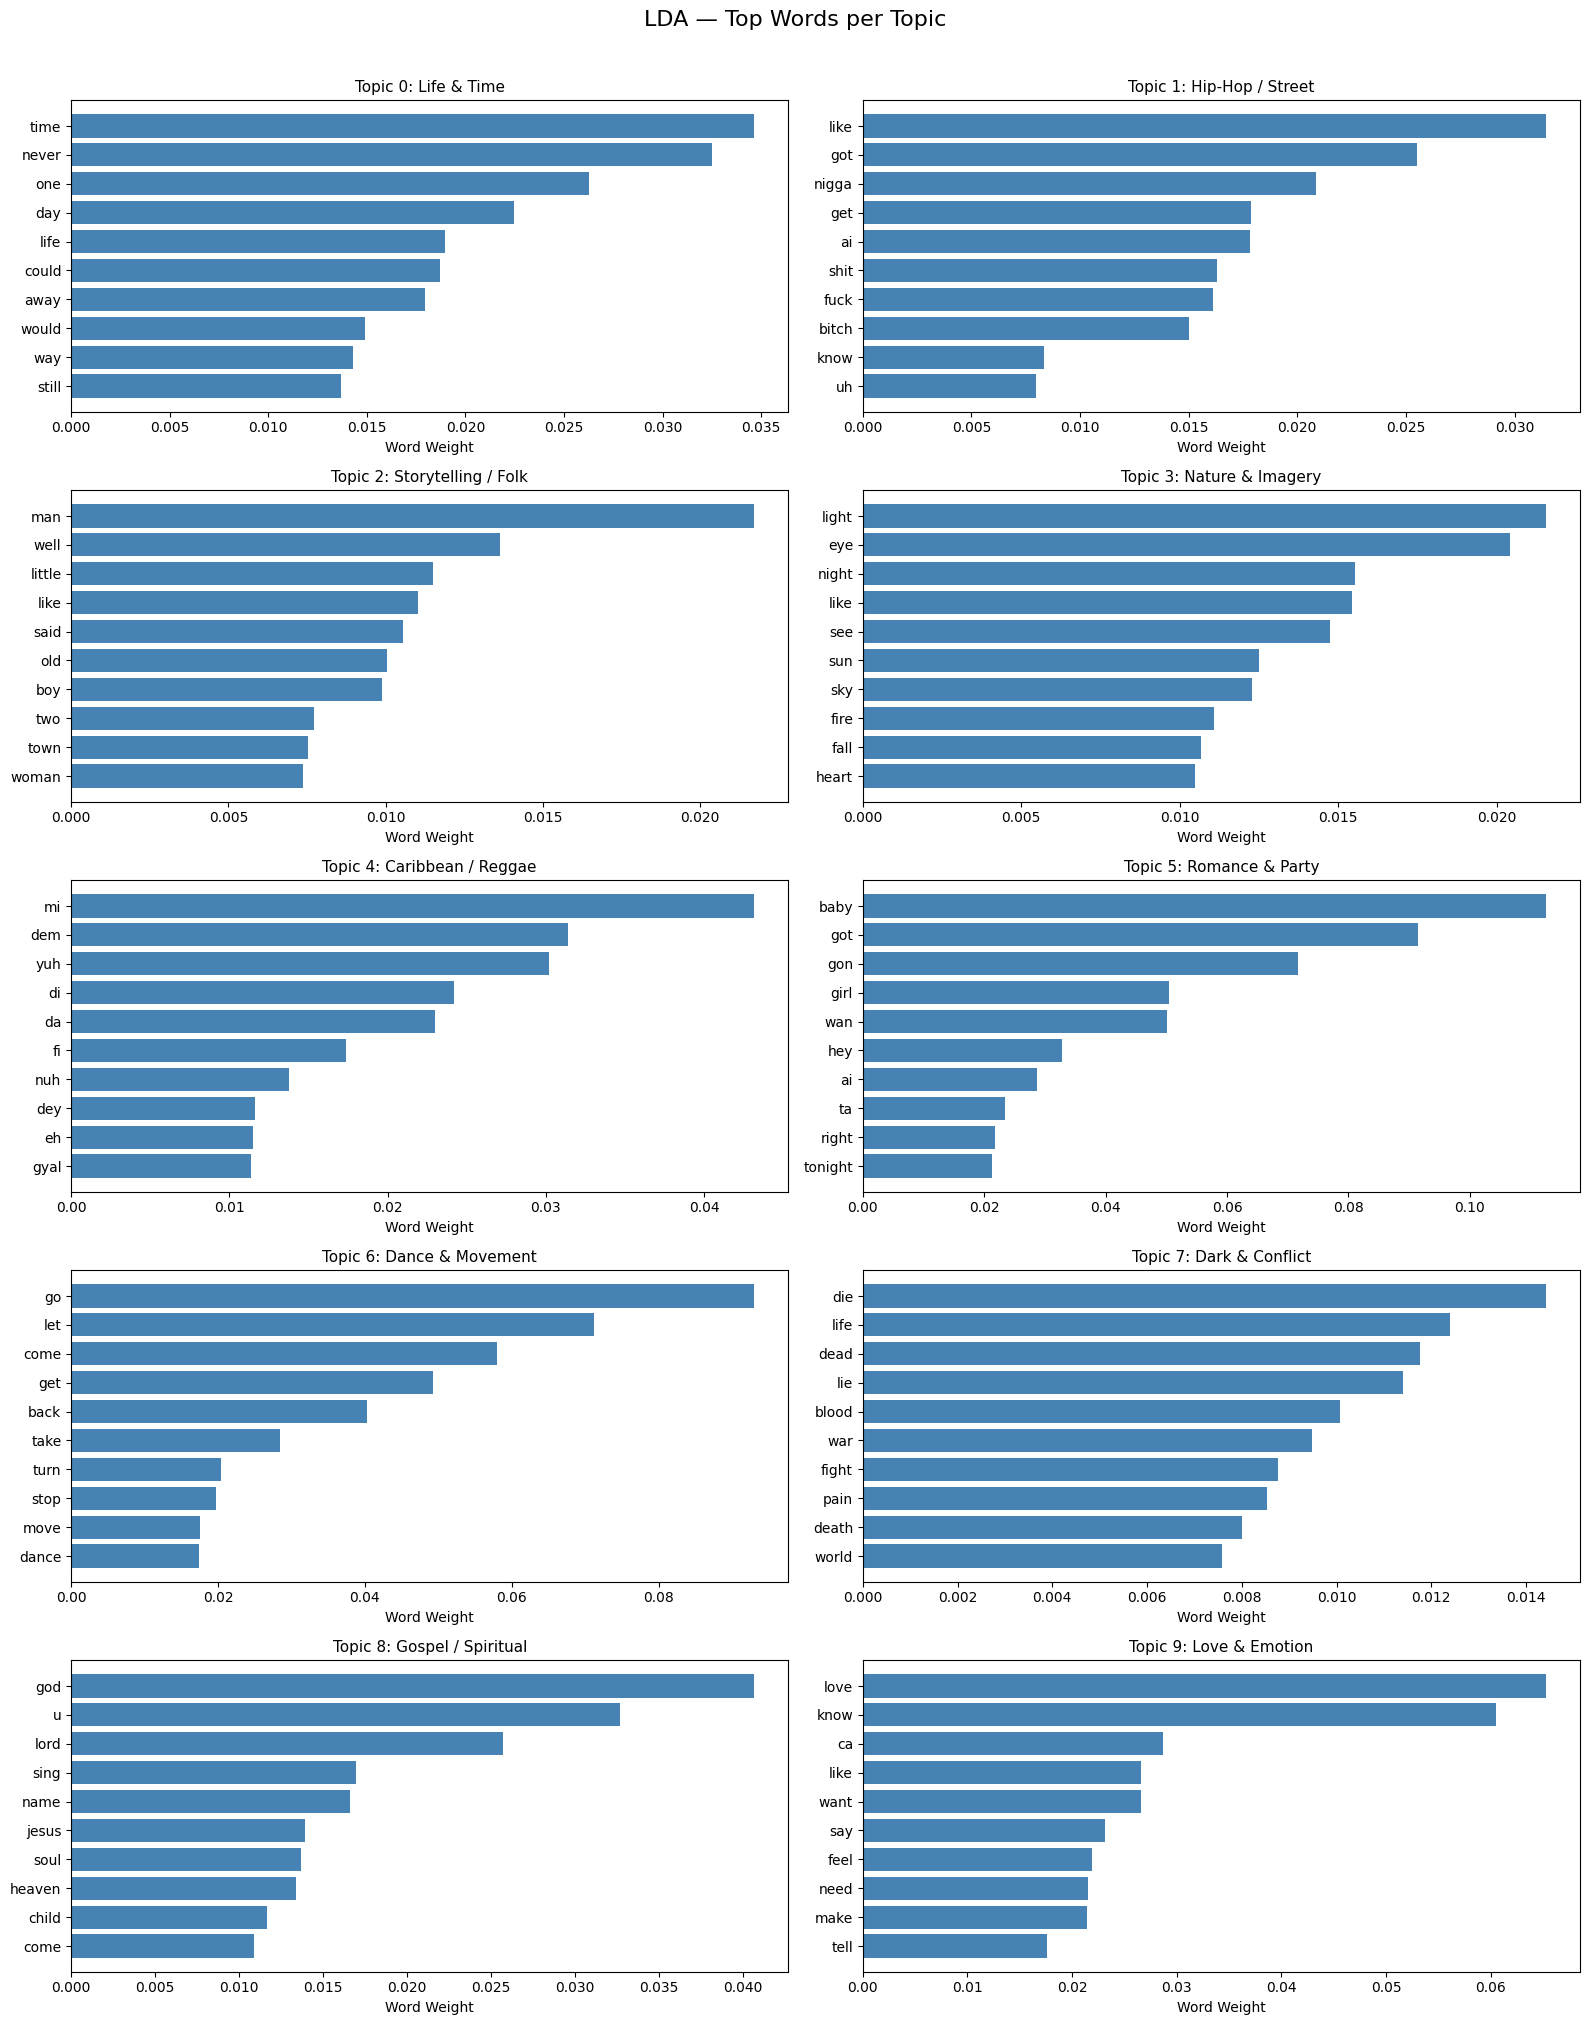

✅ Saved: lda_topic_words.png


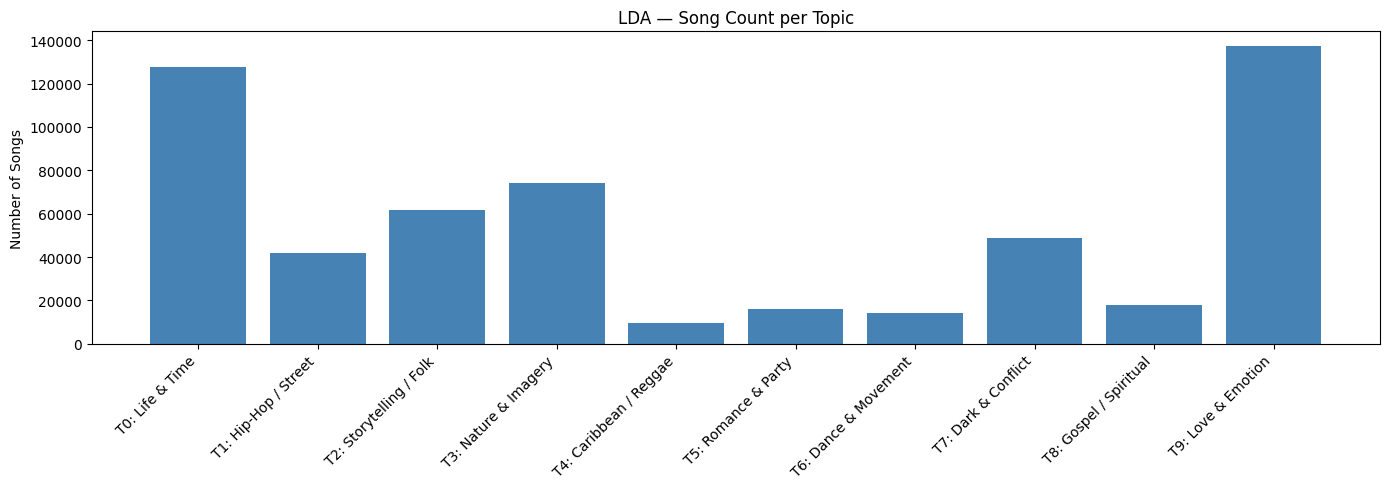

✅ Saved: lda_topic_distribution.png


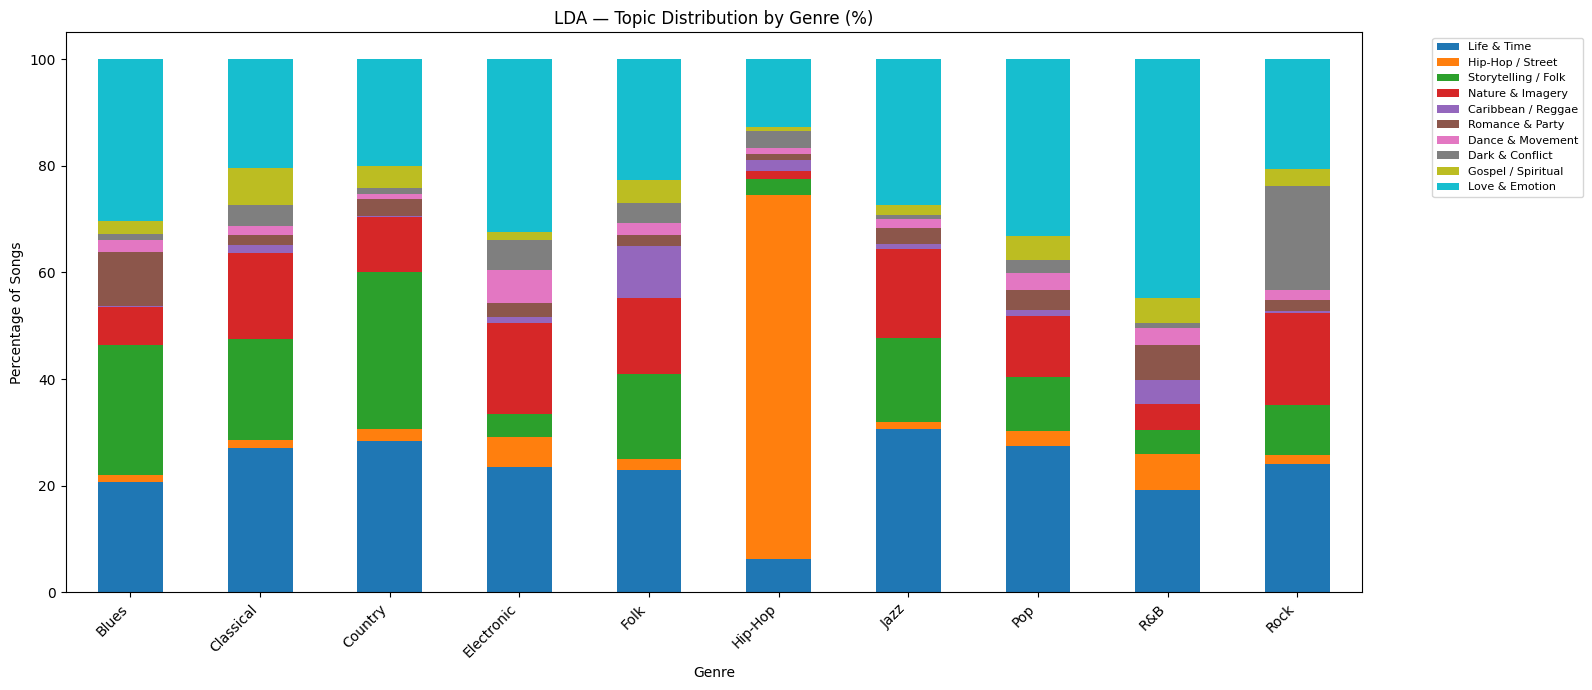

✅ Saved: lda_genre_distribution.png


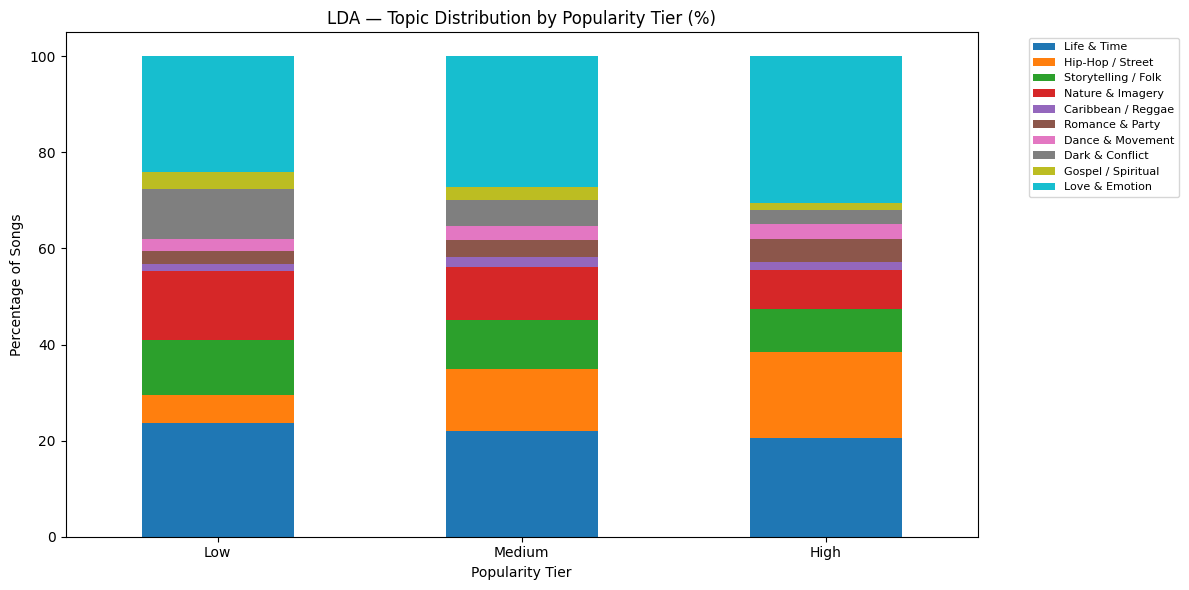

✅ Saved: lda_popularity_distribution.png


In [ ]:
# Can edit this topic label, i just came up with this first, feel free to change. 
topic_labels = {
    0: "Life & Time",
    1: "Hip-Hop / Street",
    2: "Storytelling / Folk",
    3: "Nature & Imagery",
    4: "Caribbean / Reggae",
    5: "Romance & Party",
    6: "Dance & Movement",
    7: "Dark & Conflict",
    8: "Gospel / Spiritual",
    9: "Love & Emotion"
}

# Chart 1: Word weight bar charts per topic
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for idx in range(10):
    topic_terms = lda_model.show_topic(idx, topn=10)
    words  = [w for w, _ in topic_terms]
    scores = [s for _, s in topic_terms]
    axes[idx].barh(words[::-1], scores[::-1], color='steelblue')
    axes[idx].set_title(f"Topic {idx}: {topic_labels[idx]}", fontsize=11)
    axes[idx].set_xlabel("Word Weight")

plt.suptitle("LDA — Top Words per Topic", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("lda_topic_words.png", bbox_inches='tight')
plt.show()
print("✅ Saved: lda_topic_words.png")

# Chart 2: HNo. of Songs Per Topic 
topic_counts = songs_df_lda['lda_topic'].value_counts().sort_index()
labels = [f"T{i}: {topic_labels[i]}" for i in topic_counts.index]

plt.figure(figsize=(14, 5))
plt.bar(labels, topic_counts.values, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Songs")
plt.title("LDA — Song Count per Topic")
plt.tight_layout()
plt.savefig("lda_topic_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Saved: lda_topic_distribution.png")

# Chart 3: Topic distribution by genre 
# Think this is good for something like "Does Rock have more Dark & Conflict? Does Pop dominate Romance?"
# May be redundant though so can remove
lda_genre = songs_df_lda.groupby(['genre', 'lda_topic']).size().unstack(fill_value=0)
lda_genre.columns = [topic_labels.get(c, str(c)) for c in lda_genre.columns]
lda_genre_pct = lda_genre.div(lda_genre.sum(axis=1), axis=0) * 100  # convert to %

lda_genre_pct.plot(kind='bar', stacked=True, figsize=(16, 7), colormap='tab10')
plt.title("LDA — Topic Distribution by Genre (%)")
plt.ylabel("Percentage of Songs")
plt.xlabel("Genre")
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("lda_genre_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Saved: lda_genre_distribution.png")

# ── Chart 4: Topic distribution by popularity tier ──
# Popularity score 0-100 → split into Low (0-33), Medium (34-66), High (67-100)
songs_df_lda['popularity_tier'] = pd.cut(
    songs_df_lda['popularity'],
    bins=[0, 33, 66, 100],
    labels=['Low', 'Medium', 'High']
)

lda_pop = songs_df_lda.groupby(['popularity_tier', 'lda_topic']).size().unstack(fill_value=0)
lda_pop.columns = [topic_labels.get(c, str(c)) for c in lda_pop.columns]
lda_pop_pct = lda_pop.div(lda_pop.sum(axis=1), axis=0) * 100

lda_pop_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.title("LDA — Topic Distribution by Popularity Tier (%)")
plt.ylabel("Percentage of Songs")
plt.xlabel("Popularity Tier")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("lda_popularity_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Saved: lda_popularity_distribution.png")


### NMF Portion 
- Non-Negative Matrix Factorisation
- Decomposes a large matrix of songs x words into 
    - songs x topics 
    - topics x words 

- Uses TF-IDF weighted word counts rather than raw counts in LDA. 

Training NMF — running k=20 to k=100 to find best number of topics...
✅ TF-IDF fitted: 548,698 songs × 5,000 words
  k=20  Diversity: 0.845  Recon Error: 708.7
  k=25  Diversity: 0.864  Recon Error: 704.9
  k=30  Diversity: 0.857  Recon Error: 701.2
  k=35  Diversity: 0.857  Recon Error: 698.0
  k=40  Diversity: 0.838  Recon Error: 694.7
  k=45  Diversity: 0.820  Recon Error: 691.7
  k=50  Diversity: 0.828  Recon Error: 688.5
  k=55  Diversity: 0.845  Recon Error: 685.7
  k=60  Diversity: 0.828  Recon Error: 682.8
  k=65  Diversity: 0.822  Recon Error: 680.1
  k=70  Diversity: 0.821  Recon Error: 677.8
  k=75  Diversity: 0.800  Recon Error: 674.9
  k=80  Diversity: 0.806  Recon Error: 672.6
  k=85  Diversity: 0.798  Recon Error: 670.0
  k=90  Diversity: 0.800  Recon Error: 667.9
  k=95  Diversity: 0.791  Recon Error: 665.4
  k=100  Diversity: 0.807  Recon Error: 663.0


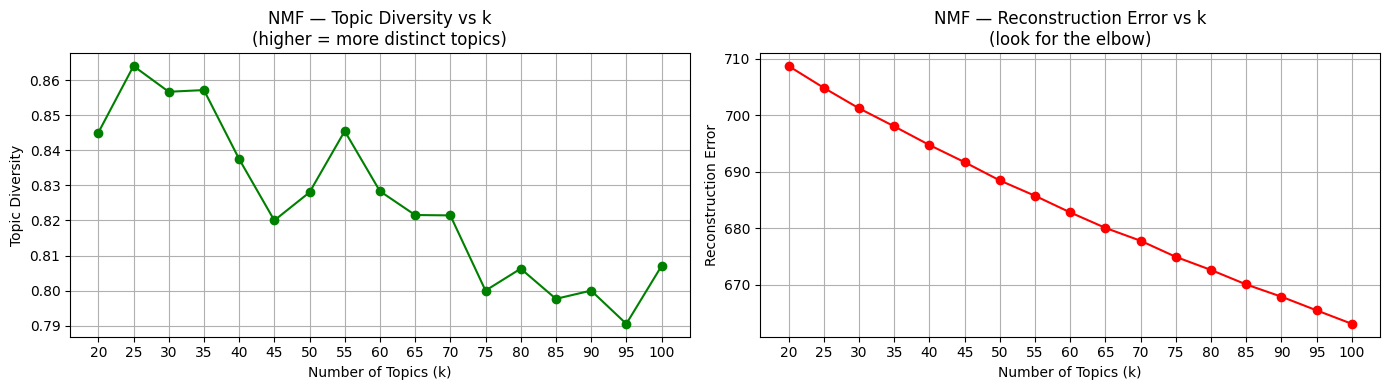

✅ Saved: ./nmf/nmf_tuning.png

── Best k by diversity = 25 ──
(Check the charts above — if diversity plateaus early, pick that earlier k)
Update NUM_TOPICS below and rerun if needed.

Training final NMF model with k=25...

── Top 10 Words per NMF Topic (k=25) ──
  Topic  0: ['ca', 'see', 'ca see', 'wo', 'believe', 'stop', 'tell', 'keep', 'help', 'ca stop']
  Topic  1: ['love', 'love love', 'heart', 'know love', 'love like', 'true', 'give', 'say love', 'give love', 'fall love']
  Topic  2: ['girl', 'man', 'little', 'well', 'good', 'boy', 'said', 'woman', 'old', 'ai']
  Topic  3: ['nigga', 'bitch', 'shit', 'fuck', 'ai', 'like', 'yo', 'ya', 'as', 'money']
  Topic  4: ['baby', 'baby baby', 'love baby', 'girl', 'baby love', 'baby know', 'babe', 'baby got', 'baby let', 'honey']
  Topic  5: ['let', 'go', 'let go', 'go go', 'go let', 'wo let', 'wo', 'let let', 'never let', 'hold']
  Topic  6: ['want', 'want want', 'want know', 'know want', 'want love', 'say', 'give', 'want see', 'love want', '

In [7]:
# Adjusting Parameters to see what works best. 

os.makedirs("./nmf", exist_ok=True)  # create folder if it doesn't exist

NMF_RESULTS_PATH = "./nmf/songs_with_nmf.csv"
NMF_MODEL_PATH   = "./nmf/nmf_model.pkl"
TFIDF_PATH       = "./nmf/tfidf_vectorizer.pkl"
TUNING_PATH      = "./nmf/tuning_results.csv"

# Load Data in like before, if not build model from scratch 
if os.path.exists(NMF_RESULTS_PATH):
    print("Loading existing NMF model...")

    songs_df_nmf = pd.read_csv(NMF_RESULTS_PATH)

    with open(NMF_MODEL_PATH, 'rb') as f:
        nmf_model = pickle.load(f)

    with open(TFIDF_PATH, 'rb') as f:
        tfidf = pickle.load(f)

    feature_names = tfidf.get_feature_names_out()
    NUM_TOPICS = nmf_model.n_components
    print(f"✅ NMF loaded! (k={NUM_TOPICS}, {len(songs_df_nmf):,} songs)")

else:
    topic_range = range(20, 101, 5)  # 5, 10, 15, 20 ... 100
    print(f"Training NMF — running k={min(topic_range)} to k={max(topic_range)} to find best number of topics...")

    # Ok I asked gpt to help with the visualisations here

    # 1. Fit TF-IDF 
    # max_features=5000: keep only the 5000 most meaningful words
    # max_df=0.85: drop words appearing in >85% of songs (too common to be meaningful) - original value
    # min_df=10: drop words appearing in fewer than 10 songs (too rare, likely noise) - orange 

    tfidf = TfidfVectorizer(max_features=5000, max_df=0.7, min_df=20, ngram_range = (1,2))
    tfidf_matrix = tfidf.fit_transform(songs_df['tokens_joined'])
    feature_names = tfidf.get_feature_names_out()
    print(f"✅ TF-IDF fitted: {tfidf_matrix.shape[0]:,} songs × {tfidf_matrix.shape[1]:,} words")

    # Check for k from 5 to 20. 
    diversity_values = []
    recon_errors     = []
    

    for k in topic_range:
        model = NMF(n_components=k, random_state=42, max_iter=400)
        model.fit_transform(tfidf_matrix)

        # Topic Diversity: fraction of top-10 keywords that are UNIQUE across all topics
        # High diversity = topics are distinct and not repeating the same words
        all_words = []
        for topic in model.components_:
            all_words.extend([feature_names[i] for i in topic.argsort()[:-11:-1]])
        diversity = len(set(all_words)) / len(all_words)
        diversity_values.append(diversity)

        # Reconstruction Error: how well NMF rebuilds the original TF-IDF matrix
        # Lower = better fit, but watch for diminishing returns
        recon_errors.append(model.reconstruction_err_)

        print(f"  k={k:2d}  Diversity: {diversity:.3f}  Recon Error: {model.reconstruction_err_:,.1f}")

    # Save results 
    tuning_df = pd.DataFrame({
        'k': list(topic_range),
        'diversity': diversity_values,
        'reconstruction_error': recon_errors
    })
    tuning_df.to_csv(TUNING_PATH, index=False)

    #  Visualisation of results 
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(list(topic_range), diversity_values, marker='o', color='green')
    axes[0].set_title("NMF — Topic Diversity vs k\n(higher = more distinct topics)")
    axes[0].set_xlabel("Number of Topics (k)")
    axes[0].set_ylabel("Topic Diversity")
    axes[0].set_xticks(list(topic_range))
    axes[0].grid(True)

    axes[1].plot(list(topic_range), recon_errors, marker='o', color='red')
    axes[1].set_title("NMF — Reconstruction Error vs k\n(look for the elbow)")
    axes[1].set_xlabel("Number of Topics (k)")
    axes[1].set_ylabel("Reconstruction Error")
    axes[1].set_xticks(list(topic_range))
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig("./nmf/nmf_tuning.png", bbox_inches='tight')
    plt.show()
    print("✅ Saved: ./nmf/nmf_tuning.png")

    # 5. Pick best k / altho should i change? since 5 is too little. I could just train to 10 
    # Strategy: pick k where diversity peaks (or stops rising significantly)
    best_k = list(topic_range)[diversity_values.index(max(diversity_values))]
    print(f"\n── Best k by diversity = {best_k} ──")
    print("(Check the charts above — if diversity plateaus early, pick that earlier k)")
    print("Update NUM_TOPICS below and rerun if needed.\n")

    NUM_TOPICS = best_k  

    # Step 6: Train final NMF with best k
    print(f"Training final NMF model with k={NUM_TOPICS}...")
    nmf_model  = NMF(n_components=NUM_TOPICS, random_state=42, max_iter=400)
    nmf_matrix = nmf_model.fit_transform(tfidf_matrix)

    # Assign dominant topic per song (highest weight = that song's main theme)
    songs_df['nmf_topic'] = nmf_matrix.argmax(axis=1)

    # Print top keywords per topic so you can label them
    print(f"\n── Top 10 Words per NMF Topic (k={NUM_TOPICS}) ──")
    for idx, topic in enumerate(nmf_model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
        print(f"  Topic {idx:2d}: {top_words}")

    # Final diversity score
    all_words = []
    for topic in nmf_model.components_:
        all_words.extend([feature_names[i] for i in topic.argsort()[:-11:-1]])
    final_diversity = len(set(all_words)) / len(all_words)
    print(f"\nFinal NMF Topic Diversity: {final_diversity:.3f}")

    # Save all
    songs_df.to_csv(NMF_RESULTS_PATH, index=False)
    songs_df_nmf = songs_df.copy()

    with open(NMF_MODEL_PATH, 'wb') as f:
        pickle.dump(nmf_model, f)

    with open(TFIDF_PATH, 'wb') as f:
        pickle.dump(tfidf, f)

    print(f"\n✅ NMF model saved! (k={NUM_TOPICS})")
    print("   → ./nmf/songs_with_nmf.csv")
    print("   → ./nmf/nmf_model.pkl")
    print("   → ./nmf/tfidf_vectorizer.pkl")
    print("   → ./nmf/tuning_results.csv")
    print("   → ./nmf/nmf_tuning.png")


In [ ]:
# Just k = 25 - trying new variables - added a ngram range here, improved model significantly
from gensim import corpora
from gensim.models.coherencemodel import CoherenceModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# ── 1. Clean contraction artifacts ───────────────────────────────────────
extra_stopwords = {'ca', 'wo', 'wan', 'gon', 'ta', 'ai', 'uh', 'ya', 'yo'}

songs_df['tokens_cleaned'] = songs_df['tokens_lemma'].apply(
    lambda tokens: [t for t in tokens if t not in extra_stopwords]
)
songs_df['tokens_joined_clean'] = songs_df['tokens_cleaned'].apply(lambda x: ' '.join(x))

# ── 2. TF-IDF (Added a bigram) ─────────────────────────────────────────────
tfidf_clean = TfidfVectorizer(
    max_features=5000,
    max_df=0.7,
    min_df=20,
    ngram_range=(1, 2)   
)
tfidf_matrix_clean = tfidf_clean.fit_transform(songs_df['tokens_joined_clean'])
feature_names_clean = tfidf_clean.get_feature_names_out()
print(f"✅ TF-IDF fitted: {tfidf_matrix_clean.shape[0]:,} songs × {tfidf_matrix_clean.shape[1]:,} words")

# ── 3. NMF at k=25 only ───────────────────────────────────────────────────
nmf_clean = NMF(n_components=25, random_state=42, max_iter=400)
nmf_matrix_clean = nmf_clean.fit_transform(tfidf_matrix_clean)

topic_words = []
for topic in nmf_clean.components_:
    top_words = [feature_names_clean[i] for i in topic.argsort()[:-11:-1]]
    topic_words.append(top_words)

print(f"\n── Top 10 Words per NMF Topic (k=25) ──")
for idx, top_words in enumerate(topic_words):
    print(f"  Topic {idx:2d}: {top_words}")

# ── 4. Coherence ──────────────────────────────────────────────────────────
dictionary = corpora.Dictionary(songs_df['tokens_cleaned'].tolist())
coherence_model = CoherenceModel(
    topics=topic_words,
    texts=songs_df['tokens_cleaned'],
    dictionary=dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
print(f"\nNMF k=25 Coherence Score (c_v): {coherence_score:.4f}")

# ── 5. Diversity ──────────────────────────────────────────────────────────
all_words = [w for topic in topic_words for w in topic]
diversity = len(set(all_words)) / len(all_words)
print(f"NMF k=25 Diversity: {diversity:.4f}")

✅ TF-IDF fitted: 548,698 songs × 5,000 words

── Top 10 Words per NMF Topic (k=25) ──
  Topic  0: ['time', 'time time', 'mind', 'long', 'every', 'every time', 'mine', 'last', 'long time', 'good time']
  Topic  1: ['love', 'love love', 'heart', 'know love', 'love like', 'true', 'give', 'say love', 'give love', 'love baby']
  Topic  2: ['man', 'back', 'home', 'well', 'little', 'old', 'said', 'boy', 'blue', 'woman']
  Topic  3: ['nigga', 'bitch', 'shit', 'fuck', 'like', 'as', 'money', 'hoe', 'fuckin', 'hit']
  Topic  4: ['baby', 'baby baby', 'love baby', 'baby love', 'baby know', 'babe', 'good', 'baby let', 'baby got', 'honey']
  Topic  5: ['let', 'go', 'let go', 'go go', 'go let', 'let let', 'never let', 'hold', 'let know', 'show']
  Topic  6: ['world', 'heart', 'fire', 'soul', 'death', 'blood', 'fall', 'dead', 'burn', 'end']
  Topic  7: ['like', 'feel', 'feel like', 'make', 'make feel', 'like like', 'feel feel', 'feeling', 'love like', 'feel good']
  Topic  8: ['want', 'want want', 'wan

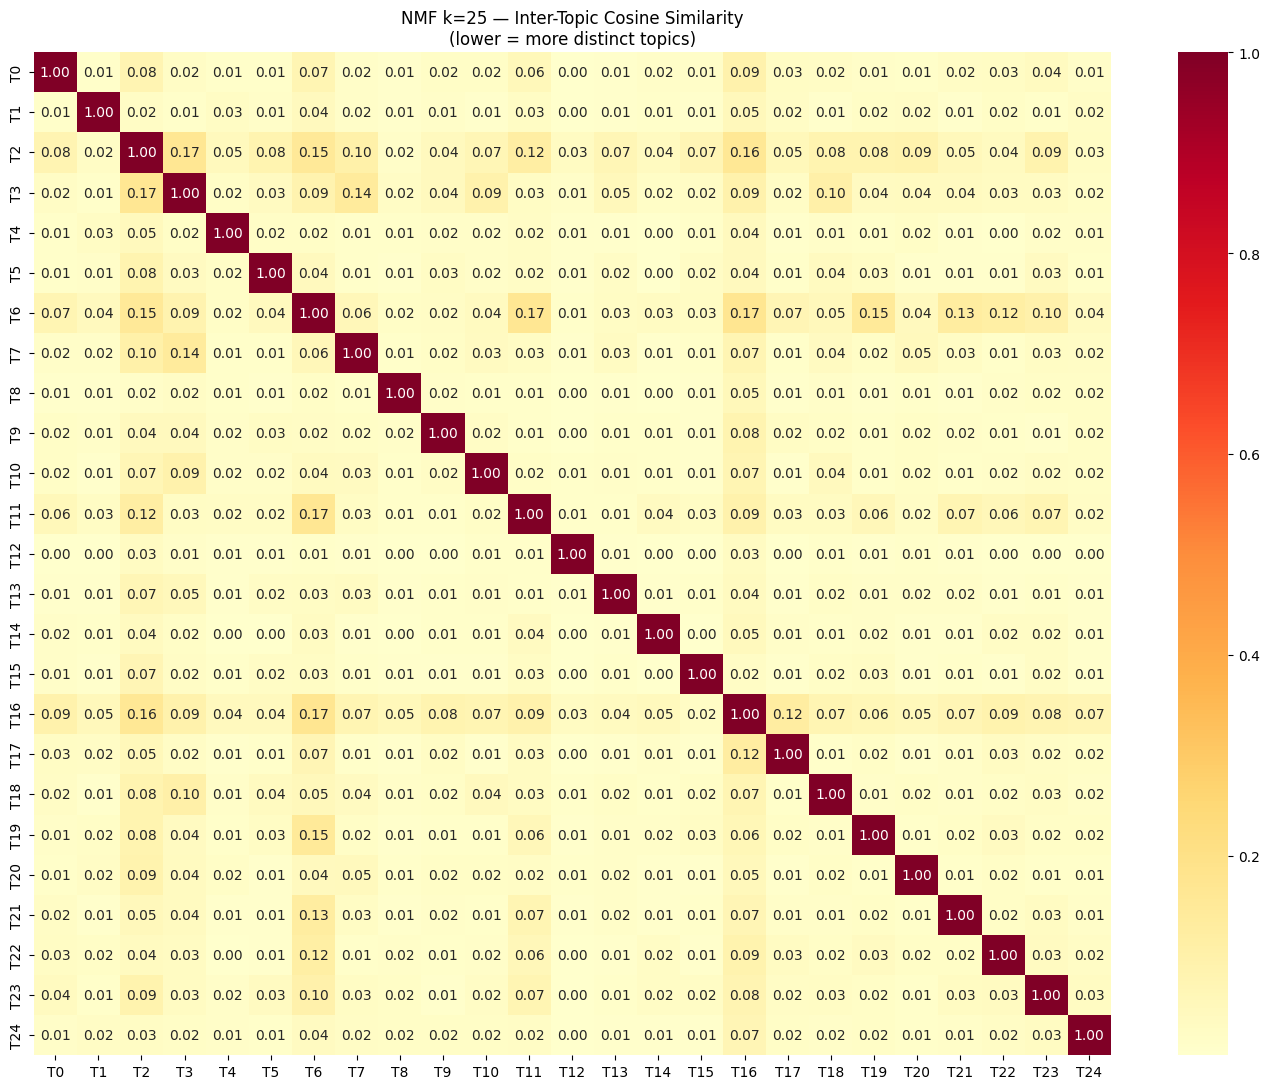

✅ Saved: nmf_similarity_heatmap.png


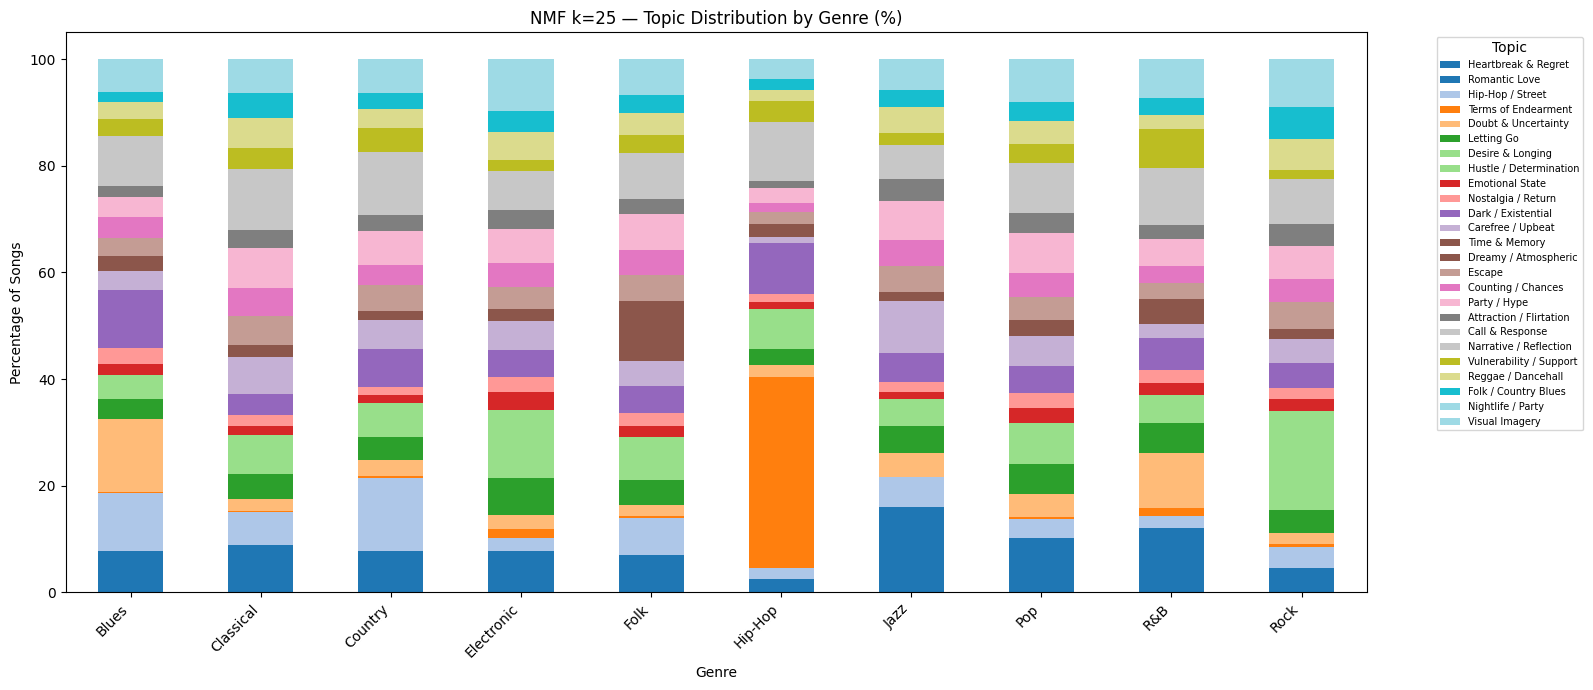

✅ Saved: nmf_genre_distribution.png


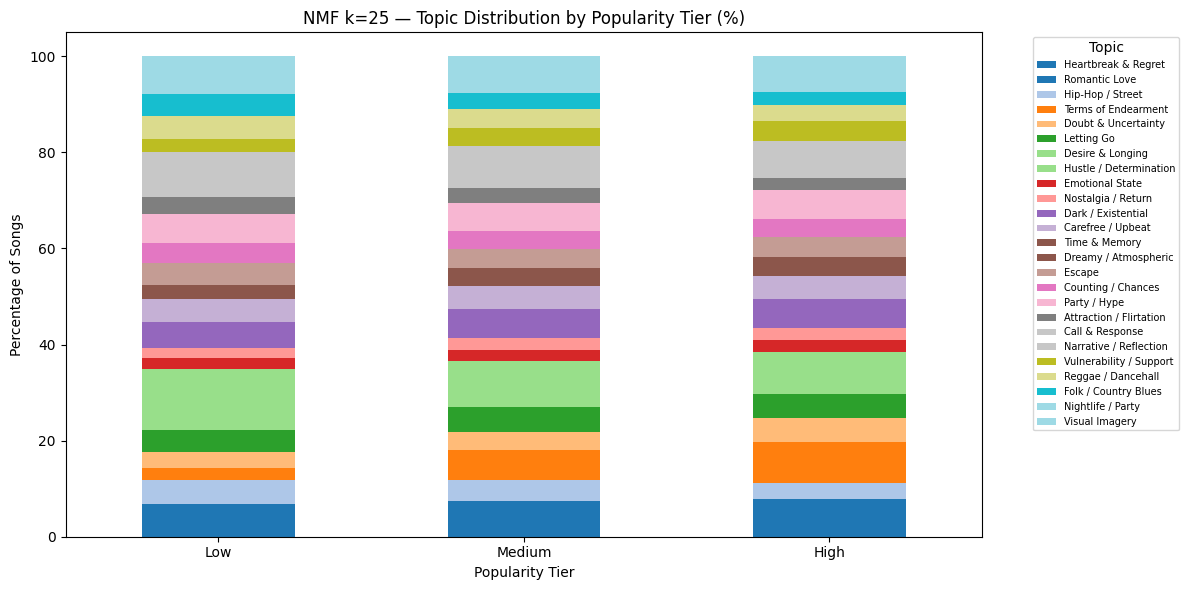

✅ Saved: nmf_popularity_distribution.png


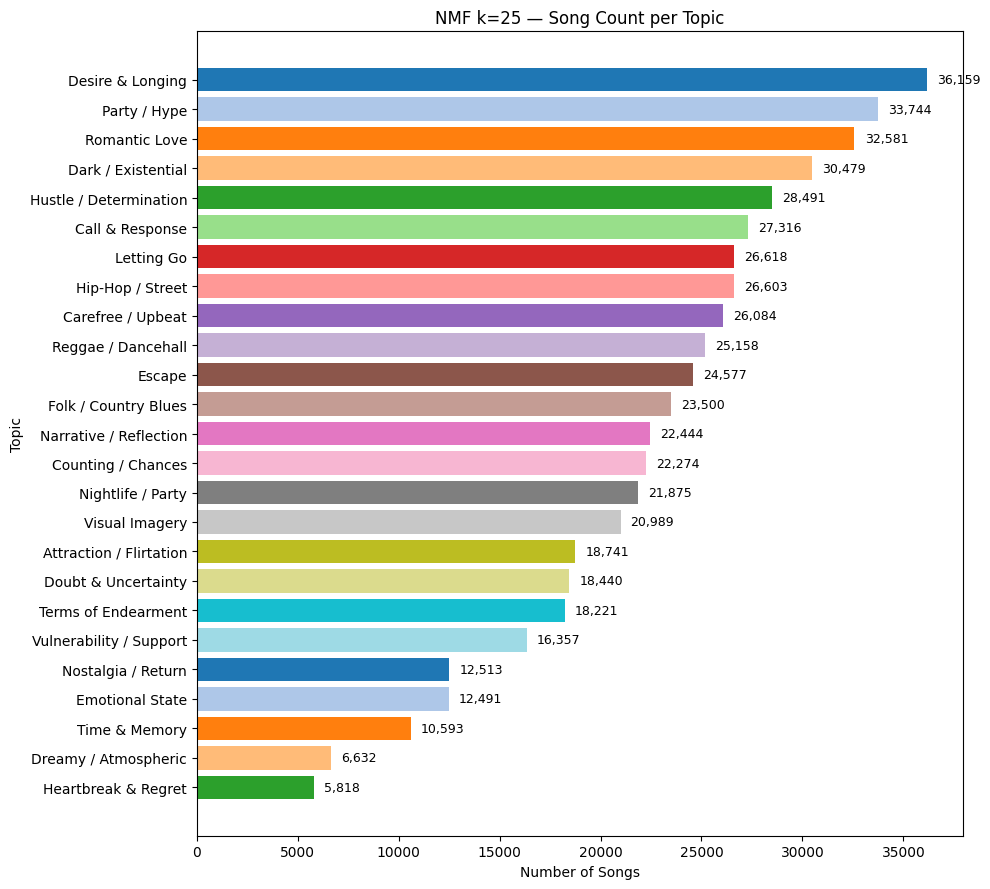

✅ Saved: nmf_topic_counts.png


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# ── Topic Labels ──────────────────────────────────────────────────────────
nmf_topic_labels = {
    0:  "Heartbreak & Regret",
    1:  "Romantic Love",
    2:  "Hip-Hop / Street",
    3:  "Terms of Endearment",
    4:  "Doubt & Uncertainty",
    5:  "Letting Go",
    6:  "Desire & Longing",
    7:  "Hustle / Determination",
    8:  "Emotional State",
    9:  "Nostalgia / Return",
    10: "Dark / Existential",
    11: "Carefree / Upbeat",
    12: "Time & Memory",
    13: "Dreamy / Atmospheric",
    14: "Escape",
    15: "Counting / Chances",
    16: "Party / Hype",
    17: "Attraction / Flirtation",
    18: "Call & Response",
    19: "Narrative / Reflection",
    20: "Vulnerability / Support",
    21: "Reggae / Dancehall",
    22: "Folk / Country Blues",
    23: "Nightlife / Party",
    24: "Visual Imagery",
}

# ── Assign dominant topic to each song ───────────────────────────────────
songs_df['nmf_topic'] = nmf_matrix_clean.argmax(axis=1)
songs_df['nmf_topic_label'] = songs_df['nmf_topic'].map(nmf_topic_labels)
songs_df_nmf = songs_df.copy()

# ── 1. Inter-Topic Cosine Similarity Heatmap ─────────────────────────────
sim_matrix = cosine_similarity(nmf_clean.components_)

plt.figure(figsize=(14, 11))
sns.heatmap(sim_matrix, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=[f"T{i}" for i in range(25)],
            yticklabels=[f"T{i}" for i in range(25)])
plt.title("NMF k=25 — Inter-Topic Cosine Similarity\n(lower = more distinct topics)")
plt.tight_layout()
plt.savefig("nmf_similarity_heatmap.png", bbox_inches='tight')
plt.show()
print("✅ Saved: nmf_similarity_heatmap.png")

# ── 2. Topic Distribution by Genre ───────────────────────────────────────
nmf_genre = songs_df_nmf.groupby(['genre', 'nmf_topic']).size().unstack(fill_value=0)
nmf_genre.columns = [nmf_topic_labels.get(c, str(c)) for c in nmf_genre.columns]
nmf_genre_pct = nmf_genre.div(nmf_genre.sum(axis=1), axis=0) * 100

nmf_genre_pct.plot(kind='bar', stacked=True, figsize=(16, 7), colormap='tab20')
plt.title("NMF k=25 — Topic Distribution by Genre (%)")
plt.ylabel("Percentage of Songs")
plt.xlabel("Genre")
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, title="Topic")
plt.tight_layout()
plt.savefig("nmf_genre_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Saved: nmf_genre_distribution.png")

# ── 3. Topic Distribution by Popularity Tier ─────────────────────────────
songs_df_nmf['popularity_tier'] = pd.cut(
    songs_df_nmf['popularity'],
    bins=[0, 33, 66, 100],
    labels=['Low', 'Medium', 'High']
)

nmf_pop = songs_df_nmf.groupby(['popularity_tier', 'nmf_topic']).size().unstack(fill_value=0)
nmf_pop.columns = [nmf_topic_labels.get(c, str(c)) for c in nmf_pop.columns]
nmf_pop_pct = nmf_pop.div(nmf_pop.sum(axis=1), axis=0) * 100

nmf_pop_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title("NMF k=25 — Topic Distribution by Popularity Tier (%)")
plt.ylabel("Percentage of Songs")
plt.xlabel("Popularity Tier")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, title="Topic")
plt.tight_layout()
plt.savefig("nmf_popularity_distribution.png", bbox_inches='tight')
plt.show()
print("✅ Saved: nmf_popularity_distribution.png")

# ── 4. Song Count per Topic (Horizontal Bar) ─────────────────────────────
topic_counts = songs_df_nmf['nmf_topic'].value_counts().sort_values(ascending = False)
topic_count_labels = [nmf_topic_labels[i] for i in topic_counts.index]

plt.figure(figsize=(10, 9))
bars = plt.barh(topic_count_labels, topic_counts.values, color=plt.cm.tab20.colors[:25])

# Add count labels at end of each bar
for bar, val in zip(bars, topic_counts.values):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=9)

plt.xlabel("Number of Songs")
plt.ylabel("Topic")
plt.title("NMF k=25 — Song Count per Topic")
plt.gca().invert_yaxis()  # Topic 0 at top
plt.tight_layout()
plt.savefig("nmf_topic_counts.png", bbox_inches='tight')
plt.show()
print("✅ Saved: nmf_topic_counts.png")